# PSYC0021: Tutorial to Extract Features from PPG Signal

## Mount Google Drive

## Install HeartPy Package

## Import packages

In [98]:
%matplotlib inline

import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import heartpy as hp
import pandas as pd
import importlib
pd.set_option("display.precision", 2)

import utils.process_ppg as process_ppg
importlib.reload(process_ppg)
from utils.process_ppg import load_PPG_signal, get_filtered_ppg, get_ppg_measures_batch

## Specify directory paths and the file containing PPG signal

In [87]:
basepath = os.path.join('data', 'mydata')
csv_files = sorted([
    f for f in os.listdir(basepath)
    if f.endswith('.csv') and f.startswith('full_labelled_')
])

if not csv_files:
    raise FileNotFoundError(f'No full_labelled CSV files found in {basepath}')

# Pick one file for demo plotting; change index to choose another recording.
fname = csv_files[0]
filepath = os.path.join(basepath, fname)

# full_labelled_001-easy.csv -> sub_id=001, exertion_level=easy
name_body = os.path.splitext(fname)[0]
sub_level = name_body.split('_')[-1]
if '-' in sub_level:
    sub_id, exertion_level = sub_level.split('-', 1)
else:
    sub_id, exertion_level = 'unknown', 'unknown'

print(f"Selected file: {filepath}")
print(f"Detected Subject: {sub_id}, Exertion Level: {exertion_level}")

sample_rate = 79.5 # Keep for filtering + feature extraction steps.

Selected file: data\mydata\full_labelled_001-easy.csv
Detected Subject: 001, Exertion Level: easy


## Load the signal

In [88]:
if filepath and os.path.exists(filepath):
    raw_signal, tElapsed = load_PPG_signal(filepath)
else:
    print(f"File not found or not specified: {filepath}")
    raw_signal, tElapsed = np.array([]), np.array([])

## Visualize raw signal

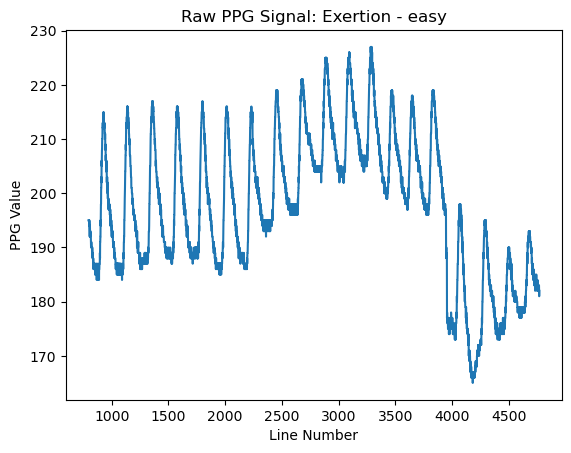

In [89]:
x_axis = np.arange(len(raw_signal))
start_x = int(sample_rate * 10)
end_x = int(sample_rate * 60)

if len(raw_signal) == 0:
    print('No PPG samples loaded. Check input parsing/path.')
elif end_x <= start_x or start_x >= len(raw_signal):
    plt.plot(x_axis, raw_signal)
    plt.xlabel('Line Number')
    plt.ylabel('PPG Value')
    plt.title('Raw PPG Signal: ' + 'Exertion - ' + exertion_level)
else:
    end_x = min(end_x, len(raw_signal))
    plt.plot(x_axis[start_x:end_x], raw_signal[start_x:end_x])
    plt.xlabel('Line Number')
    plt.ylabel('PPG Value')
    plt.title('Raw PPG Signal: ' + 'Exertion - ' + exertion_level)

## Filter the signal and Plot


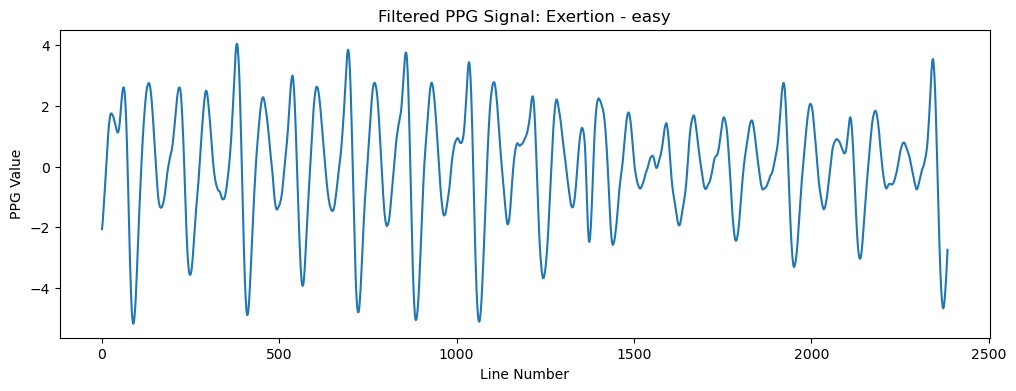

In [90]:
filtered = get_filtered_ppg(raw_signal, sample_rate=sample_rate)
if len(filtered) > 30 * sample_rate:
    start_indx = int(((len(filtered) // 2) - (15 * sample_rate)))
    end_indx = int(((len(filtered) // 2) + (15 * sample_rate)))
    filtered = filtered[start_indx:end_indx]

if len(filtered) == 0:
    print('Filtered signal is empty. Try a different file or sample rate.')
else:
    plt.figure(figsize=(12, 4))
    x_axis = np.arange(len(filtered))
    plt.plot(x_axis, filtered)
    plt.xlabel('Line Number')
    plt.ylabel('PPG Value')
    plt.title('Filtered PPG Signal: ' + 'Exertion - ' + exertion_level)

## Compute the features using 'heartpy' Python package <br>
Plot the signal with peaks identified and print the measures derived

In [91]:
if len(filtered) == 0:
    raise ValueError('Cannot compute heartpy features: filtered signal is empty.')

wd, m = hp.process(filtered, sample_rate=sample_rate)
# print(wd.keys())
m['exertion_level'] = exertion_level

# display computed features
for measure in m.keys():
    print(measure, m[measure])

bpm 57.72611464968152
ibi 1039.3909301555777
sdnn 129.00292838569706
sdsd 107.17843007579704
rmssd 233.25868135379176
pnn20 1.0
pnn50 1.0
hr_mad 88.05031446540875
sd1 164.37687832013702
sd2 88.04409644241697
s 45466.4286467222
sd1/sd2 1.8669835339572551
breathingrate 0.30396676630021785
exertion_level easy


### Plot PPG signal with detected and rejected peaks

Text(0.5, 1.0, 'Filtered PPG Signal with Detected Peaks: Exertion - easy')

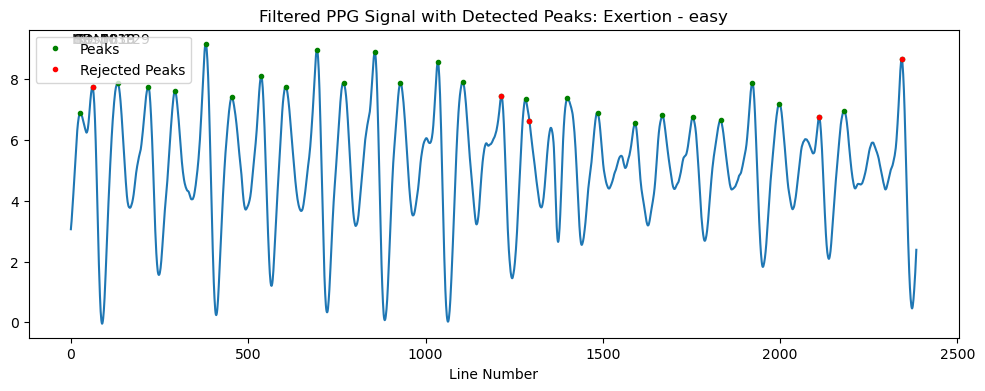

In [92]:
# Plot PPG signal with detected and rejected peaks.
plt.figure(figsize=(12, 4))
x_axis = np.arange(len(wd['hr']))
plt.plot(x_axis, wd['hr'])
plt.plot(np.array(wd['peaklist']), wd['hr'][wd['peaklist']], '.', color='g', label='Peaks')
plt.plot(np.array(wd['removed_beats']), wd['hr'][wd['removed_beats']], '.', color='r', label='Rejected Peaks')
mx = max(wd['hr'])
plt.text(2, mx, 'HR: ' + str(int(round(m['bpm']))))
plt.text(5, mx, 'IBI: ' + str(int(round(m['ibi']))))
plt.text(8, mx, 'SDNN: ' + str(int(round(m['sdnn']))))
plt.text(11, mx, 'Resp: ' + str(int(round(m['breathingrate'] * 60))))

plt.legend()
plt.xlabel('Line Number')
plt.title('Filtered PPG Signal with Detected Peaks: ' + 'Exertion - ' + exertion_level)

### Plot Breathing signal derived from PPG signal

Text(0.5, 1.0, 'Breathing Signal')

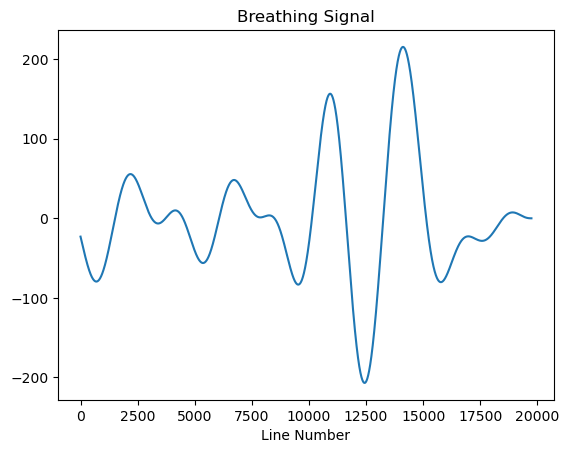

In [93]:
# Plot breathing signal derived from PPG signal
x_axis_br = np.arange(len(wd['breathing_signal']))
plt.plot(x_axis_br, wd['breathing_signal'])
plt.xlabel('Line Number')
plt.title('Breathing Signal')

## Batch processing for feature extraction

In [101]:
get_ppg_measures_batch(datapath=os.path.join('data', 'mydata'), sample_rate=sample_rate)

Found 14 PPG signal files under data\mydata
Processing: 001 : full_labelled_001-easy.csv
Processing: 001 : full_labelled_001-hard.csv
Processing: 002 : full_labelled_002-easy.csv
Processing: 002 : full_labelled_002-hard.csv
Processing: 003 : full_labelled_003-easy.csv
Processing: 003 : full_labelled_003-hard.csv
Processing: 004 : full_labelled_004-easy.csv
Processing: 004 : full_labelled_004-hard.csv
Processing: 005 : full_labelled_005-easy.csv
Processing: 005 : full_labelled_005-hard.csv
Processing: 006 : full_labelled_006-easy.csv


c:\Users\Shoib\anaconda3\envs\FeatExtract\Lib\site-packages\heartpy\analysis.py:677: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  interp = UnivariateSpline(x, rrlist, k=3)
c:\Users\Shoib\anaconda3\envs\FeatExtract\Lib\site-packages\numpy\ma\core.py:5403: RuntimeWarning: Mean of empty slice
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
c:\Users\Shoib\anaconda3\envs\FeatExtract\Lib\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Processing: 006 : full_labelled_006-hard.csv
Processing: 007 : full_labelled_007-easy.csv
Processing: 007 : full_labelled_007-hard.csv


## Next Steps
As an outcome of this tutorial, two files will be generated (in basepath directory) comprising of PPG derived features for each of the signals present in the directory <br>
1. PPG_features.csv -> To be used with WEKA for further ML Model Development <br>
2. PPG_features.pkl -> To be used for ML Model Development using Python

In [96]:
diag_files = ['full_labelled_003-easy.csv', 'full_labelled_005-hard.csv']
diag_base = os.path.join('data', 'mydata')

tests = [
    {'sample_rate': 79.5, 'windowsize': 0.75, 'bpmmin': 40, 'bpmmax': 180},
    {'sample_rate': 64.0, 'windowsize': 0.75, 'bpmmin': 40, 'bpmmax': 180},
    {'sample_rate': 64.0, 'windowsize': 1.2, 'bpmmin': 40, 'bpmmax': 180},
    {'sample_rate': 64.0, 'windowsize': 1.2, 'bpmmin': 35, 'bpmmax': 200},
]

for fn in diag_files:
    fp = os.path.join(diag_base, fn)
    raw_sig, _ = load_PPG_signal(fp)
    print('\n===', fn, '===')
    print('raw_len:', len(raw_sig), 'raw_std:', float(np.std(raw_sig)) if len(raw_sig) else None)

    for t in tests:
        sr = t['sample_rate']
        filtered_sig = get_filtered_ppg(raw_sig, sample_rate=sr)
        if len(filtered_sig) > int(30 * sr):
            s = int((len(filtered_sig) // 2) - (15 * sr))
            e = int((len(filtered_sig) // 2) + (15 * sr))
            filtered_sig = filtered_sig[s:e]
        try:
            wd_t, m_t = hp.process(
                filtered_sig,
                sample_rate=sr,
                windowsize=t['windowsize'],
                bpmmin=t['bpmmin'],
                bpmmax=t['bpmmax']
            )
            print(
                f"ok sr={sr} win={t['windowsize']} bpmrange={t['bpmmin']}-{t['bpmmax']} ",
                f"bpm={m_t.get('bpm'):.2f} peaks={len(wd_t.get('peaklist', []))} rejected={len(wd_t.get('removed_beats', []))}"
            )
        except Exception as ex:
            print(
                f"fail sr={sr} win={t['windowsize']} bpmrange={t['bpmmin']}-{t['bpmmax']} -> {str(ex).splitlines()[1] if str(ex).splitlines() else str(ex)}"
            )


=== full_labelled_003-easy.csv ===
raw_len: 7952 raw_std: 24.803543841849258
fail sr=79.5 win=0.75 bpmrange=40-180 -> ----------------
fail sr=64.0 win=0.75 bpmrange=40-180 -> ----------------
fail sr=64.0 win=1.2 bpmrange=40-180 -> ----------------
fail sr=64.0 win=1.2 bpmrange=35-200 -> ----------------

=== full_labelled_005-hard.csv ===
raw_len: 10564 raw_std: 9.576396894017325
fail sr=79.5 win=0.75 bpmrange=40-180 -> ----------------
ok sr=64.0 win=0.75 bpmrange=40-180  bpm=111.45 peaks=49 rejected=16
ok sr=64.0 win=1.2 bpmrange=40-180  bpm=115.32 peaks=54 rejected=20
ok sr=64.0 win=1.2 bpmrange=35-200  bpm=115.32 peaks=54 rejected=20


c:\Users\Shoib\anaconda3\envs\FeatExtract\Lib\site-packages\heartpy\analysis.py:677: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  interp = UnivariateSpline(x, rrlist, k=3)


In [97]:
# Check whether 003-easy fails only in center window or everywhere.
fp = os.path.join('data', 'mydata', 'full_labelled_003-easy.csv')
raw_sig, _ = load_PPG_signal(fp)
sr = 64.0
f_sig = get_filtered_ppg(raw_sig, sample_rate=sr)
print('filtered_len:', len(f_sig))

win = int(30 * sr)
starts = [0, max(0, (len(f_sig)//2) - (win//2)), max(0, len(f_sig)-win)]
labels = ['start', 'middle', 'end']

for lbl, st in zip(labels, starts):
    seg = f_sig[st:st+win] if len(f_sig) >= win else f_sig
    try:
        wd_t, m_t = hp.process(seg, sample_rate=sr, windowsize=0.75, bpmmin=40, bpmmax=180)
        print(lbl, 'OK bpm=', round(float(m_t['bpm']), 2), 'peaks=', len(wd_t['peaklist']), 'rejected=', len(wd_t['removed_beats']))
    except Exception as ex:
        print(lbl, 'FAIL', str(ex).splitlines()[1] if str(ex).splitlines() else str(ex))

filtered_len: 4582
start FAIL ----------------
middle FAIL ----------------
end OK bpm= 98.79 peaks= 52 rejected= 18


In [100]:
import inspect
print('defaults:', get_ppg_measures_batch.__defaults__)
src = inspect.getsource(get_ppg_measures_batch)
print(src.splitlines()[0])
print('has_status_header:', 'sample_rate_used' in src and 'status' in src)

defaults: (64.0,)
def get_ppg_measures_batch(datapath, sample_rate=64.0):
has_status_header: True
